In [1]:
import ROOT
import numpy as np
import scipy
import matplotlib.pyplot as plt
from array import array

In [2]:
savefig = 0

In [3]:
c = 299792458*1e3 ##speed light in mm/sec

In [4]:
def intersect_time(rX_mag,X_th,X_ph,q_th,q_ph,radius,length):
    if(rX_mag==0):
        a = c*c*np.sin(q_th)*np.sin(q_th)
        b = 0
        d = -radius*radius
        t1 = (-b + np.sqrt(b*b-4*a*d))/(2*a)
        t2 = (length/2 )/(c*np.cos(q_th))
        t3 = (-length/2 )/(c*np.cos(q_th))
        return min(t1,max(t2,t3))
    elif((rX_mag*rX_mag*np.sin(X_th)*np.sin(X_th) >= radius*radius) or (rX_mag*np.cos(X_th) >= length/2) or ((rX_mag*np.cos(X_th)) <= -length/2)): 
        return -1000
    else:
        a = c*c*np.sin(q_th)*np.sin(q_th)
        b = 2*c*(np.sin(q_th)*np.cos(q_ph)*rX_mag*np.cos(X_ph)*np.sin(X_th)+np.sin(q_th)*np.sin(q_ph)*rX_mag*np.sin(X_ph)*np.sin(X_th))
        d = rX_mag*rX_mag*np.sin(X_th)*np.sin(X_th)-radius*radius
        t1 = (-b + np.sqrt(b*b-4*a*d))/(2*a)
        t2 = (length/2 - rX_mag*np.cos(X_th))/(c*np.cos(q_th))
        t3 = (-length/2 - rX_mag*np.cos(X_th))/(c*np.cos(q_th))
        return min(t1,max(t2,t3))

In [5]:
def time_delay(intersect_t,rX_mag,X_th,X_ph,q_th,q_ph,t):
    if (intersect_t<0): 
        return -1000
    elif(rX_mag==0):
        return t
    else:
        inter_dist = np.sqrt(rX_mag*rX_mag + intersect_t*intersect_t*c*c + 2*c*intersect_t*(rX_mag*np.cos(X_th)*np.cos(q_th)+rX_mag*np.cos(X_ph)*np.sin(X_th) * np.cos(q_ph)*np.sin(q_th)+rX_mag*np.sin(X_ph)*np.sin(X_th)*np.sin(q_ph)*np.sin(q_th)))
        dt = intersect_t + t - inter_dist/c
        return dt

In [6]:
file_path1 = "../pythia8316/examples/bg_z_qq/bg_z_qq_82.root"

In [7]:
file_outpath = "./outputs/Z_timing/bg_z_qq_82_timing.root"

In [8]:
tZ1=ROOT.TChain("t1")
tZ1.AddFile(file_path1)
tZ2=ROOT.TChain("t1")
tZ2.AddFile(file_path1)
tZ3=ROOT.TChain("t1")
tZ3.AddFile(file_path1)

1

In [9]:
t_jet = ROOT.TChain("t_jet")
t_jet.AddFile(file_path1)

1

In [10]:
entries_jet = t_jet.GetEntries()

In [11]:
entries_jet

1304248

In [12]:
entriesZH = tZ2.GetEntries()

In [13]:
entriesZH

68658857

In [14]:
jet_energy = []
jet_px = []
jet_py = []
jet_pz = []
jet_event = []
jet_multiplicity = []
jet_constituent = []

In [15]:
cons=[]

In [16]:
for i in range(0,entries_jet):
    if(i%100000==0): print(i)
    t_jet.GetEntry(i)
    jet_energy.append(t_jet.jet_e)
    jet_px.append(t_jet.jet_px)
    jet_py.append(t_jet.jet_py)
    jet_pz.append(t_jet.jet_pz)
    jet_event.append(t_jet.num_event)
    jet_multiplicity.append(t_jet.num_jet)
    for j in range(0,len(t_jet.constituents)):
        cons.append(t_jet.constituents[j])
    jet_constituent.append(cons)
    cons=[]

0
100000
200000
300000
400000
500000
600000
700000
800000
900000
1000000
1100000
1200000
1300000


In [17]:
len(jet_event)

1304248

In [18]:
jet_inv = []
jet_eta = []
jet_phi = []

In [19]:
for i in range(0,len(jet_energy)):
    p_rad = np.sqrt(jet_px[i]**2+jet_py[i]**2+jet_pz[i]**2)
    inv = np.sqrt(jet_energy[i]**2-(jet_px[i]**2+jet_py[i]**2+jet_pz[i]**2))
    jet_inv.append(inv)
    eta = 2*np.log((p_rad+jet_pz[i])/(p_rad-jet_pz[i]))
    jet_eta.append(eta)
    jet_phi.append(np.atan2(jet_py[i],jet_px[i]))

/var/folders/_c/zy9yzddj6ql7_c56txmblmch0000gn/T/ipykernel_48117/2535393089.py:3: RuntimeWarning: invalid value encountered in sqrt
  inv = np.sqrt(jet_energy[i]**2-(jet_px[i]**2+jet_py[i]**2+jet_pz[i]**2))


Text(0.5, 1.0, 'invariant sum')

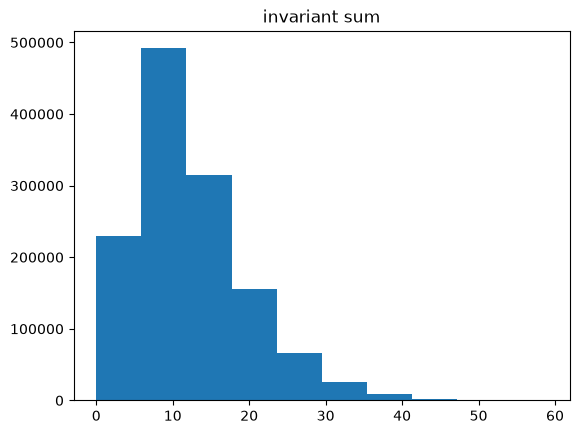

In [20]:
plt.hist(jet_inv)
plt.title("invariant sum")

Text(0.5, 1.0, 'jet_energy')

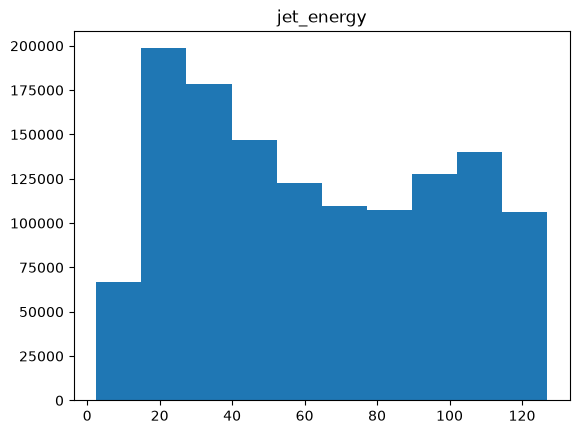

In [21]:
plt.hist(jet_energy)
plt.title("jet_energy")

(array([4.00000e+00, 2.30000e+01, 3.98000e+02, 2.26600e+04, 3.15272e+05,
        5.69360e+05, 3.54744e+05, 4.12310e+04, 5.21000e+02, 3.50000e+01]),
 array([-33.71105918, -27.64477841, -21.57849764, -15.51221686,
         -9.44593609,  -3.37965532,   2.68662546,   8.75290623,
         14.819187  ,  20.88546778,  26.95174855]),
 <BarContainer object of 10 artists>)

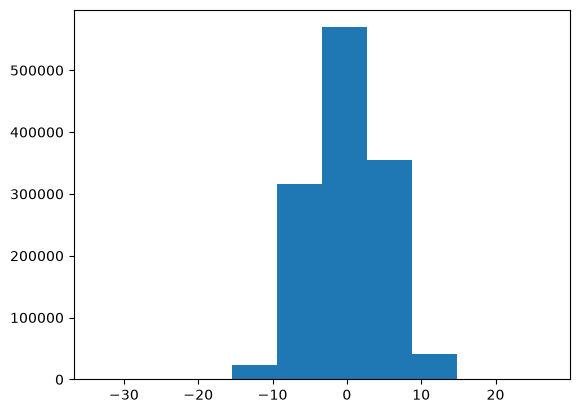

In [22]:
plt.hist(jet_eta)

In [23]:
## get the parton information
final_q_energy = []
final_q_x = []
final_q_y = []
final_q_z = []
final_q_theta = []
final_q_phi = []
final_q_px = []
final_q_py = []
final_q_pz = []
final_q_pid = []
final_q_entry = []
final_q_t = []
final_q_event = []
final_q_smearing = []

In [24]:
import random

In [25]:
for jentry in range(0,entriesZH):
    if(jentry%10000000==0): print(jentry)
    tZ1.GetEntry(jentry)
    if(tZ1.pid!=23 and tZ1.pid!=-23): continue
    if(tZ1.isCarbonCopy==1): continue
    dl = tZ1.DaughterList
    ls = tZ1.list
    for i in range(0,len(dl)):
        tZ2.GetEntry(jentry-ls+int(dl[i]))
        if(tZ2.isCarbonCopy==0):
            final_q_energy.append(tZ2.energy)
            final_q_x.append(tZ2.x)
            final_q_y.append(tZ2.y)
            final_q_z.append(tZ2.z)
            final_q_t.append(tZ2.t)
            final_q_phi.append(tZ2.phi)
            final_q_theta.append(tZ2.theta)
            final_q_px.append(tZ2.px)
            final_q_py.append(tZ2.py)
            final_q_pz.append(tZ2.pz)
            final_q_pid.append(tZ2.pid)
            final_q_entry.append(tZ2.MC_event)
            final_q_event.append(jentry-ls+dl[i])
        elif(tZ2.isCarbonCopy==1):
            final_pos = tZ2.final_carbon_copy
            tZ3.GetEntry(jentry-ls+final_pos)
            final_q_energy.append(tZ3.energy)
            final_q_x.append(tZ3.x)
            final_q_y.append(tZ3.y)
            final_q_z.append(tZ3.z)
            final_q_t.append(tZ3.t)
            final_q_phi.append(tZ3.phi)
            final_q_theta.append(tZ3.theta)
            final_q_px.append(tZ3.px)
            final_q_py.append(tZ3.py)
            final_q_pz.append(tZ3.pz)
            final_q_pid.append(tZ3.pid)
            final_q_entry.append(tZ3.MC_event)
            final_q_event.append(jentry-ls+final_pos)

0
10000000
20000000
30000000
40000000
50000000
60000000


In [26]:
## get the final products of parton
q_prod_energy = []
q_prod_x = []
q_prod_y = []
q_prod_z = []
q_prod_t = []
q_prod_px = []
q_prod_py = []
q_prod_pz = []
q_prod_jet = []
q_prod_smearing = []
for i in range(0,len(final_q_energy)):
    if(i%100000==0): print(i)
    tZ1.GetEntry(final_q_event[i])
    dl = np.unique(tZ1.DaughterListRec)
    ls = tZ1.list
    single_q_energy = []
    single_q_x = []
    single_q_y = []
    single_q_z = []
    single_q_t = []
    single_q_px = []
    single_q_py = []
    single_q_pz = []
    single_q_jet = []
    single_q_smearing = []
    if(len(dl)==0):
        smr = random.gauss(0,0.1)
        single_q_energy.append(tZ1.energy)
        single_q_x.append(tZ1.x)
        single_q_y.append(tZ1.y)
        single_q_z.append(tZ1.z)
        single_q_t.append(tZ1.t)
        single_q_px.append(tZ1.px)
        single_q_py.append(tZ1.py)
        single_q_pz.append(tZ1.pz)
        single_q_jet.append(tZ1.list)
        single_q_smearing.append(smr)
    for j in range(0,len(dl)):
        smr = random.gauss(0,0.1)
        tZ2.GetEntry(final_q_event[i]-ls+int(dl[j]))
        if(tZ2.isFinal==0): continue
        single_q_energy.append(tZ2.energy)
        single_q_x.append(tZ2.x)
        single_q_y.append(tZ2.y)
        single_q_z.append(tZ2.z)
        single_q_t.append(tZ2.t)
        single_q_px.append(tZ2.px)
        single_q_py.append(tZ2.py)
        single_q_pz.append(tZ2.pz)
        single_q_jet.append(tZ2.list)
        single_q_smearing.append(smr)
    q_prod_energy.append(single_q_energy)
    q_prod_x.append(single_q_x)
    q_prod_y.append(single_q_y)
    q_prod_z.append(single_q_z)
    q_prod_t.append(single_q_t)
    q_prod_px.append(single_q_px)
    q_prod_py.append(single_q_py)
    q_prod_pz.append(single_q_pz)
    q_prod_jet.append(single_q_jet)
    q_prod_smearing.append(single_q_smearing)

0
100000
200000
300000
400000
500000
600000
700000
800000
900000


In [27]:
len(final_q_energy)

999622

In [28]:
## compress jet:
compress_jet_energy = []
compress_jet_px = []
compress_jet_py = []
compress_jet_pz = []
compress_jet_constituents = []
compress_jet_eta = []
compress_jet_phi = []
MC=jet_event[0]
compre_jet_energy = []
compre_jet_px = []
compre_jet_py = []
compre_jet_pz = []
compre_jet_constituents = []
compre_jet_eta = []
compre_jet_phi = []
for i in range(0,len(jet_energy)):
    if(jet_event[i]!=MC):
        compress_jet_energy.append(compre_jet_energy)
        compress_jet_px.append(compre_jet_px)
        compress_jet_py.append(compre_jet_py)
        compress_jet_pz.append(compre_jet_pz)
        compress_jet_constituents.append(compre_jet_constituents)
        compress_jet_eta.append(compre_jet_eta)
        compress_jet_phi.append(compre_jet_phi)
        compre_jet_energy = []
        compre_jet_px = []
        compre_jet_py = []
        compre_jet_pz = []
        compre_jet_constituents = []
        compre_jet_eta = []
        compre_jet_phi = []
        MC = jet_event[i]
    compre_jet_energy.append(jet_energy[i])
    compre_jet_px.append(jet_px[i])
    compre_jet_py.append(jet_py[i])
    compre_jet_pz.append(jet_pz[i])
    compre_jet_constituents.append(jet_constituent[i])
    compre_jet_eta.append(jet_eta[i])
    compre_jet_phi.append(jet_phi[i])
    if(i==len(jet_energy)-1):
        compress_jet_energy.append(compre_jet_energy)
        compress_jet_px.append(compre_jet_px)
        compress_jet_py.append(compre_jet_py)
        compress_jet_pz.append(compre_jet_pz)
        compress_jet_constituents.append(compre_jet_constituents)
        compress_jet_eta.append(compre_jet_eta)
        compress_jet_phi.append(compre_jet_phi)
        compre_jet_energy = []
        compre_jet_px = []
        compre_jet_py = []
        compre_jet_pz = []
        compre_jet_constituents = []
        compre_jet_eta = []
        compre_jet_phi = []
        MC = jet_event[i]

In [29]:
## calculate the angular separation:
final_q_phi = []
final_q_eta = []
for i in range(0,len(final_q_energy)):
    q_phi = np.atan2(final_q_py[i],final_q_px[i])
    q_prad = np.sqrt(final_q_px[i]**2+final_q_py[i]**2+final_q_pz[i]**2)
    q_theta = np.acos(final_q_pz[i]/q_prad)
    q_eta = 2*np.log((final_q_pz[i]+q_prad)/(q_prad-final_q_pz[i]))
    final_q_phi.append(q_phi)
    final_q_eta.append(q_eta)

In [30]:
## minimal angular separation:
min_R = []
min_R_arg = []
for i in range(0,len(final_q_energy)):
    R = []
    R_alt = []
    for j in range(0,len(compress_jet_energy[final_q_entry[i]])):
        del_phi = final_q_phi[i]-compress_jet_phi[final_q_entry[i]][j]
        delta_phi = np.atan2(np.sin(del_phi),np.cos(del_phi))
        jet_rad = np.sqrt(compress_jet_px[final_q_entry[i]][j]**2+compress_jet_py[final_q_entry[i]][j]**2+compress_jet_pz[final_q_entry[i]][j]**2)
        jet_theta = np.acos(compress_jet_pz[final_q_entry[i]][j]/jet_rad)
        delta_eta = final_q_eta[i]-compress_jet_eta[final_q_entry[i]][j]
        R.append(np.sqrt(delta_phi**2+delta_eta**2))
    min_R.append(np.min(R))
    min_R_arg.append(np.argmin(R))

Text(0.5, 1.0, 'R for single Z')

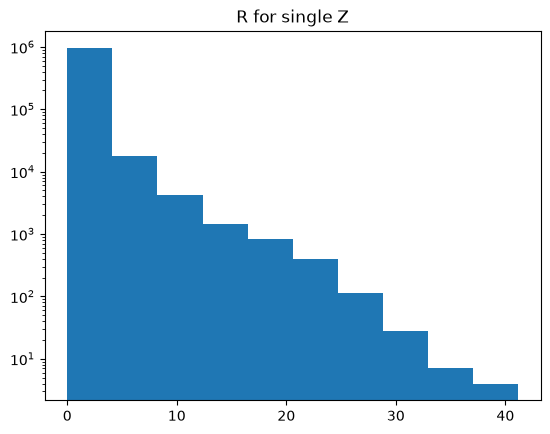

In [31]:
plt.hist(min_R,log=True)
plt.title("R for single Z")

In [32]:
len(min_R)

999622

In [33]:
##missing rate:
k=0
for i in range(0,len(min_R)):
    if(min_R[i]>=0.8):
        k+=1

In [34]:
k/len(min_R)

0.1823089127690267

In [35]:
## another look at the unassigned quarks:
unass_energy = []
unass_phi = []
unass_eta = []
for i in range(0,len(min_R)):
    if(min_R[i]<=0.8): continue
    unass_energy.append(final_q_energy[i])
    unass_phi.append(final_q_phi[i])
    unass_eta.append(final_q_eta[i])
        

(array([ 4644., 22419., 18059., 12827., 10401.,  9432., 10657., 13368.,
        18522., 61911.]),
 array([  0.39143613,  12.35229252,  24.3131489 ,  36.27400529,
         48.23486167,  60.19571806,  72.15657445,  84.11743083,
         96.07828722, 108.0391436 , 119.99999999]),
 <BarContainer object of 10 artists>)

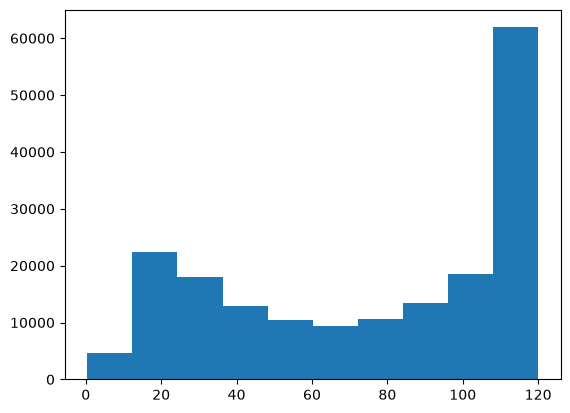

In [36]:
plt.hist(unass_energy)

(array([18072., 18286., 18239., 18081., 18318., 18435., 18336., 18106.,
        18033., 18334.]),
 array([-3.14156901e+00, -2.51325305e+00, -1.88493710e+00, -1.25662114e+00,
        -6.28305185e-01,  1.07707112e-05,  6.28326726e-01,  1.25664268e+00,
         1.88495864e+00,  2.51327459e+00,  3.14159055e+00]),
 <BarContainer object of 10 artists>)

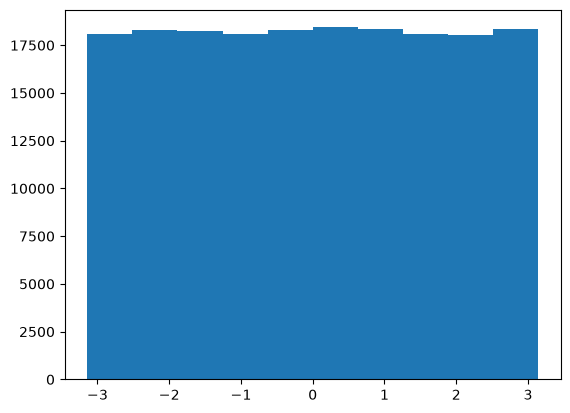

In [37]:
plt.hist(unass_phi)

(array([7.0000e+00, 1.6000e+02, 3.4090e+03, 2.6387e+04, 4.5070e+04,
        5.6480e+04, 3.4932e+04, 1.4888e+04, 8.7900e+02, 2.8000e+01]),
 array([-33.48443757, -27.12777942, -20.77112128, -14.41446314,
         -8.057805  ,  -1.70114686,   4.65551128,  11.01216942,
         17.36882757,  23.72548571,  30.08214385]),
 <BarContainer object of 10 artists>)

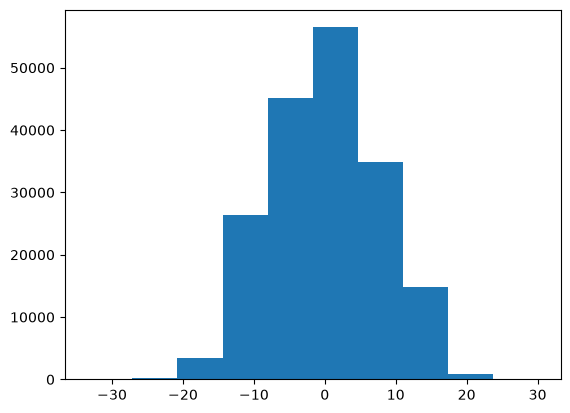

In [38]:
plt.hist(unass_eta)

In [ ]:
##non-displaced energy:
E_nd = []
for i in range(0,len(jet_constituent)):
    if (i%100000==0): print(i)
    ene = []
    for j in range(0,len(jet_constituent[i])):
        tZ1.GetEntry(jet_event[i]+jet_constituent[i][j])
        if(tZ1.isCharged==0): continue
        if(np.sqrt(tZ1.x**2+tZ1.y**2+tZ1.z**2)>1.0): continue
        ene.append(tZ1.energy)
    E_nd.append(np.sum(ene))

0
100000
200000
300000
400000
500000
600000
700000
800000


In [ ]:
plt.hist(E_nd)

In [ ]:
compress_E_nd=[]
compre_E_nd=[]
MC=jet_event[0]
for i in range(0,len(jet_energy)):
    if(jet_event[i]!=MC):
        compress_E_nd.append(compre_E_nd)
        compre_E_nd = []
        MC = jet_event[i]
    compre_E_nd.append(E_nd[i])
    if(i==len(jet_energy)-1):
        compress_E_nd.append(compre_E_nd)
        compre_E_nd = []
        MC = jet_event[i]

In [ ]:
## jet assignment:
jet_assignment = []
for i in range(0,len(final_q_energy)):
    if(min_R[i]>0.8): jet_assignment.append(-1)
    else: jet_assignment.append(min_R_arg[i])

In [ ]:
## portion of energy/assigned jet energy:
E_total = []
E_injet = []
assign_jet_energy = np.zeros(len(final_q_energy))
for i in range(0,len(final_q_energy)):
    if(jet_assignment[i]==-1): 
        continue
    E_total.append(np.sum(q_prod_energy[i]))
    e_inj = 0
    for j in range(0,len(q_prod_energy[i])):
        if(q_prod_jet[i][j] in compress_jet_constituents[final_q_entry[i]][jet_assignment[i]]):
            e_inj+=q_prod_energy[i][j]
    E_injet.append(e_inj)
    assign_jet_energy[i] = compress_jet_energy[final_q_entry[i]][jet_assignment[i]]

In [ ]:
len(E_total)+k

In [ ]:
len(assign_jet_energy)

In [ ]:
E_ratio = []
for i in range(0,len(E_total)):
    E_ratio.append(E_injet[i]/E_total[i])

In [ ]:
plt.hist(E_ratio)

In [ ]:
## hardest assignment+E_nd cut:
N = len(final_q_energy)
hardest_x = np.zeros(N)
hardest_y = np.zeros(N)
hardest_z = np.zeros(N)
hardest_t = np.zeros(N)
hardest_px = np.zeros(N)
hardest_py = np.zeros(N)
hardest_pz = np.zeros(N)
hardest_energy = np.zeros(N)
smearing = np.zeros(N)
jet_energy_cut = np.zeros(N)

for i in range(0,N):
    if(jet_assignment[i]==-1): continue
    if(compress_E_nd[final_q_entry[i]][jet_assignment[i]]>10.): continue
    jet_energy_cut[i] = assign_jet_energy[i]
    for j in range(0,len(q_prod_energy[i])):
        if(q_prod_jet[i][j] in compress_jet_constituents[final_q_entry[i]][jet_assignment[i]]):
            if(hardest_energy[i]<q_prod_energy[i][j]):
                hardest_energy[i]=q_prod_energy[i][j]
                hardest_x[i]=q_prod_x[i][j]
                hardest_y[i]=q_prod_y[i][j]
                hardest_z[i]=q_prod_z[i][j]
                hardest_t[i]=q_prod_t[i][j]
                hardest_px[i]=q_prod_px[i][j]
                hardest_py[i]=q_prod_py[i][j]
                hardest_pz[i] = q_prod_pz[i][j]
                smearing[i] = q_prod_smearing[i][j]

In [ ]:
hardest_x_truncate = []
hardest_y_truncate = []
hardest_z_truncate = []
hardest_t_truncate = []
hardest_px_truncate = []
hardest_py_truncate = []
hardest_pz_truncate = []
hardest_energy_truncate = []
hardest_smearing_truncate = []
jet_energy_truncate = []

for i in range(0,N):
    if(hardest_energy[i]==0): continue
    hardest_energy_truncate.append(hardest_energy[i])
    hardest_x_truncate.append(hardest_x[i])
    hardest_y_truncate.append(hardest_y[i])
    hardest_z_truncate.append(hardest_z[i])
    hardest_t_truncate.append(hardest_t[i])
    hardest_px_truncate.append(hardest_px[i])
    hardest_py_truncate.append(hardest_py[i])
    hardest_pz_truncate.append(hardest_pz[i])
    hardest_smearing_truncate.append(smearing[i])
    jet_energy_truncate.append(jet_energy_cut[i])

In [ ]:
plt.hist(hardest_energy_truncate)

In [ ]:
len(hardest_energy_truncate)

In [ ]:
len(E_total)

In [ ]:
hardest_timing = []
hardest_timing_smr = []
energy_passcut = []
jet_energy_passcut = []
vertex_cut = 0
detect_cut = 0
energy_cut = 0
for i in range(0,len(hardest_energy_truncate)):
    r_rad = np.sqrt(hardest_x_truncate[i]**2+hardest_y_truncate[i]**2+hardest_z_truncate[i]**2)
    if(r_rad<1.):
        vertex_cut+=1
        continue
    if(hardest_energy_truncate[i]<2.):
        energy_cut+=1
        continue
    if(jet_energy_truncate[i]<10.):
        continue
    p_rad = np.sqrt(hardest_px_truncate[i]**2+hardest_py_truncate[i]**2+hardest_pz_truncate[i]**2)
    pos_th = np.acos(hardest_z_truncate[i]/r_rad)
    pos_ph = np.atan2(hardest_y_truncate[i],hardest_x_truncate[i])
    mom_th = np.acos(hardest_pz_truncate[i]/p_rad)
    mom_ph = np.atan2(hardest_py_truncate[i],hardest_px_truncate[i])
    int_t = intersect_time(r_rad,pos_th,pos_ph,mom_th,mom_ph,2100,4400)
    if(int_t<0.): 
        detect_cut+=1
        continue
    dt = time_delay(int_t,r_rad,pos_th,pos_ph,mom_th,mom_ph,hardest_t_truncate[i]/c)*1e9
    hardest_timing.append(dt)
    hardest_timing_smr.append(dt+hardest_smearing_truncate[i])
    energy_passcut.append(hardest_energy_truncate[i])
    jet_energy_passcut.append(jet_energy_truncate[i])

In [ ]:
vertex_cut

In [ ]:
detect_cut

In [ ]:
plt.hist(hardest_timing,log=True,bins = 20)
plt.title("delayed time (semilog) (Single Z portal)")
plt.xlabel("ns")
plt.ylabel("number of events")

In [ ]:
energy_OI = []
jet_energy_OI = []
for j in range(0,len(hardest_timing)):
    if(hardest_timing[j]>0.2):
        energy_OI.append(energy_passcut[j])
        jet_energy_OI.append(jet_energy_passcut[j])
        print(j)
        print(hardest_timing[j])
        print(hardest_timing_smr[j])

In [ ]:
energy_OI

In [ ]:
jet_energy_OI

In [ ]:
np.max(hardest_timing_smr)

In [ ]:
plt.hist(hardest_timing_smr,log=True,bins = 30)
mean = np.mean(hardest_timing_smr)
plt.axvline(mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean:.4f}')
plt.axvline(0.6, color='black', linestyle='dashed', linewidth=2, label="cut")
plt.legend()
plt.title("delayed time (semilog) (Single Z portal)")
plt.xlabel("ns")
plt.ylabel("number of events")

In [ ]:
plt.hist(energy_passcut,bins=20,range = (0,20))

In [ ]:
plt.hist(jet_energy_passcut,bins = 20,range = (0,20))

In [ ]:
output_file = ROOT.TFile(file_outpath, "RECREATE")
t_out = ROOT.TTree("t_out","t_out")

delayed_t = array('f', [0.0])
delayed_t_smr = array('f', [0.0])
energy = array('f',[0.0])
jet_energy = array('f',[0.0])
t_out.Branch("delayed_t", delayed_t, "delayed_t/F")
t_out.Branch("delayed_t_smr", delayed_t_smr, "delayed_t/F")
t_out.Branch("energy", energy, "energy/F")
t_out.Branch("jet_energy", jet_energy, "jet_energy/F")


for i in range(0,len(hardest_timing)):
    delayed_t[0] = hardest_timing[i]
    delayed_t_smr[0] = hardest_timing_smr[i]
    energy[0] = energy_passcut[i]
    jet_energy[0] = jet_energy_passcut[i]
    t_out.Fill()


output_file.Write()
output_file.Close()

In [ ]:
np.max(hardest_timing_smr)

In [ ]:
np.min(hardest_timing_smr)